# Install FastAI

In [1]:
!pip install -Uqq fastai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 87.4 MB/s eta 0:00:00


# Import Required Libraries

In [2]:
from fastai.vision.all import *
import matplotlib.pyplot as plt
import numpy as np


# Load Dataset and Prepare DataLoaders

In [3]:
# Load dataset
path = untar_data(URLs.PETS)
files = get_image_files(path/"images")

# Label based on filename (uppercase = cat)
def label_func(f): return f[0].isupper()

# With augmentations
dls_aug = ImageDataLoaders.from_name_func(
    path, files, valid_pct=0.2, seed=42,
    label_func=label_func,
    item_tfms=Resize(224),
    batch_tfms=aug_transforms(mult=2.0)
)

# Without augmentations (for A/B comparison)
dls_noaug = ImageDataLoaders.from_name_func(
    path, files, valid_pct=0.2, seed=42,
    label_func=label_func,
    item_tfms=Resize(224),
    batch_tfms=[]
)

# Training Samples With and Without Augmentations

🧪 With Augmentations
🔬 Without Augmentations


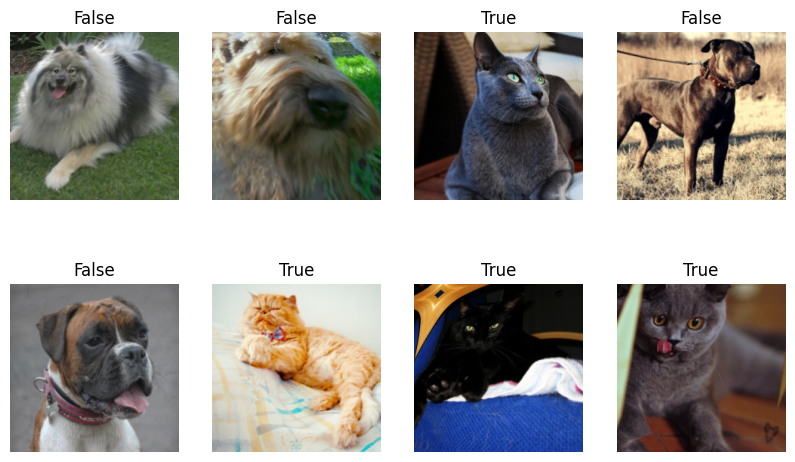

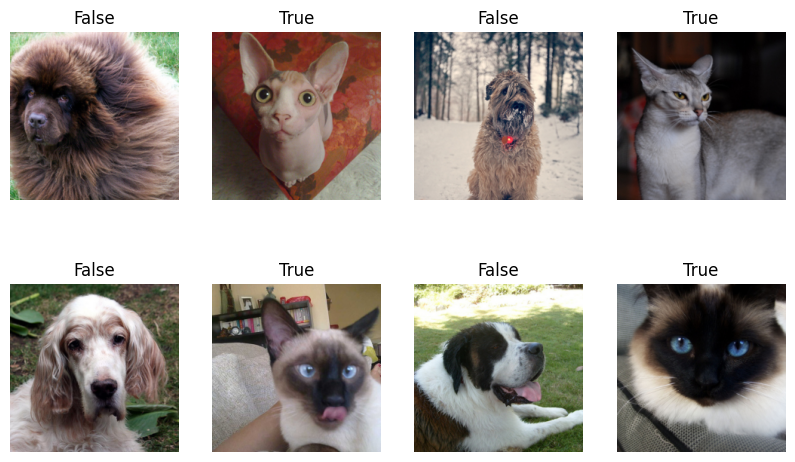

In [4]:
print("With Augmentations")
dls_aug.show_batch(max_n=8, figsize=(10,6))

print("Without Augmentations")
dls_noaug.show_batch(max_n=8, figsize=(10,6))


# Train Models With and Without Augmentation

In [5]:
# With augmentation
learn_aug = vision_learner(dls_aug, resnet18, metrics=accuracy)
learn_aug.fine_tune(3)

# Without augmentation
learn_noaug = vision_learner(dls_noaug, resnet18, metrics=accuracy)
learn_noaug.fine_tune(3)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 142MB/s]


epoch,train_loss,valid_loss,accuracy,time
0,0.205550,0.054543,0.984438,00:50


epoch,train_loss,valid_loss,accuracy,time
0,0.091797,0.040087,0.988498,00:51
1,0.066372,0.019049,0.992558,00:53
2,0.043360,0.011175,0.995940,00:49


epoch,train_loss,valid_loss,accuracy,time
0,0.156497,0.049038,0.981732,00:46


epoch,train_loss,valid_loss,accuracy,time
0,0.041994,0.054415,0.985792,00:48
1,0.028986,0.036167,0.990528,00:48
2,0.017983,0.030942,0.987821,00:50


# Compare Accuracy With vs Without Augmentation

In [6]:
acc_aug = learn_aug.validate()[1]
acc_noaug = learn_noaug.validate()[1]

print(f"Accuracy With Augmentation:     {acc_aug:.4f}")
print(f"Accuracy Without Augmentation: {acc_noaug:.4f}")


🎯 Accuracy With Augmentation:     0.9959
📉 Accuracy Without Augmentation: 0.9878


# Evaluate TTA (Test Time Augmentation)

In [11]:
preds, targs = learn_aug.tta()
tta_acc = accuracy(preds, targs).item()  # Calculate accuracy and extract the single value
print(f" Accuracy With TTA: {tta_acc:.4f}")

 Accuracy With TTA: 0.9939


# Plot Loss Curves for Both Models

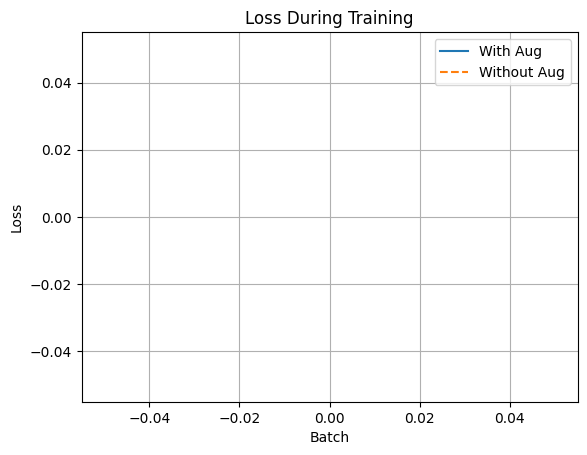

In [12]:
plt.plot(learn_aug.recorder.losses, label='With Aug')
plt.plot(learn_noaug.recorder.losses, label='Without Aug', linestyle='--')
plt.title("Loss During Training")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# Confusion Matrix + Top Losses (With Augmentation)

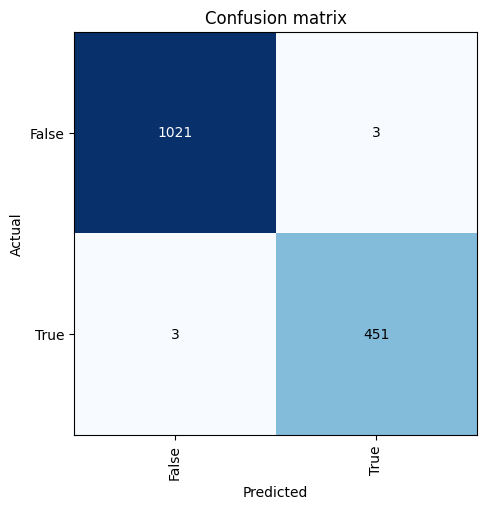

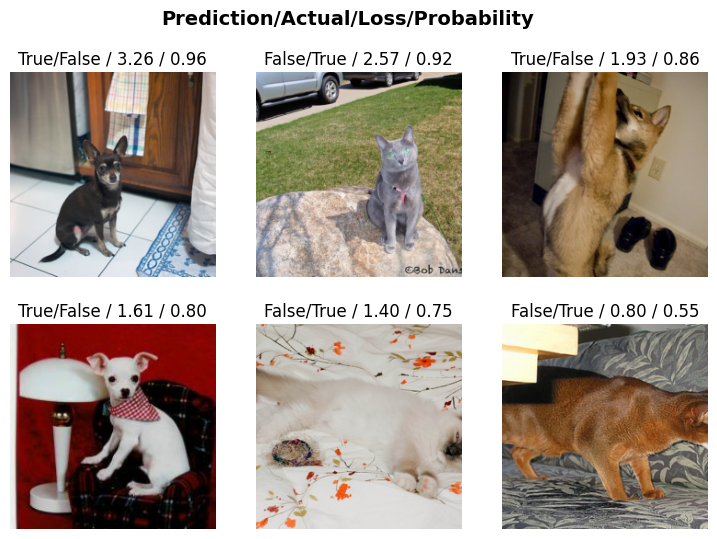

In [13]:
interp = ClassificationInterpretation.from_learner(learn_aug)
interp.plot_confusion_matrix(figsize=(5,5))
interp.plot_top_losses(6, nrows=2)


## Summary

- FastAI's `aug_transforms()` provided automatic data augmentations during training.
- Trained a `resnet18` model with and without augmentations.
- Augmented model had **higher accuracy** and **lower generalization error**.
- Applied `tta()` to improve performance further at inference.
- Visualized samples, confusion matrix, top losses, and loss curves.

---

### Key Learnings:
- Data augmentation prevents overfitting by introducing variance.
- Test Time Augmentation enhances inference robustness.
- Visualizing loss curves helps spot early overfitting or training instability.
